In [44]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import pandas as pd

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

GPU is available
Number of GPUs: 1
GPU Name: NVIDIA TITAN Xp


In [2]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 5
n_var = 50
n_components = 7
n_datapoints = 20000
locs_range = 2
batch_size = 32

In [17]:
class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3, locs_range=(0., 10.)):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.locs_range = locs_range
        self.scale=1e-4

        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)

    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device

        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.1 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.1 * torch.rand(self.n_latent, self.n_var, device=device))

                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 5 * torch.ones(self.n_var, device=device), constraint=constraints.positive)
                
                z = pyro.sample('z', dist.Categorical(logits=torch.ones(self.n_components, device=device)), infer={"enumerate": "parallel"})
                latent = pyro.sample('latent', dist.Normal(locs[z], scales[z]).to_event(1))
                out_mu = latent @ transform_matrix + intercept[z]

                if data is not None:
                    softmax_shift = pyro.param('softmax_shift', out_mu.detach().exp().sum(-1).mean().log())
                    logits = out_mu - torch.log(total_counts) + l.log() - softmax_shift
                    recon = pyro.sample('obs', dist.NegativeBinomial(total_count=total_counts, logits=logits).to_event(1), obs=data)
                    return recon

    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device

        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std).to_event(1))
                weights_probs = pyro.sample('z', dist.Categorical(logits=self.classifier(latent)), infer={"enumerate": "parallel"})


In [18]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range[0]
    scales = torch.ones(n_components, n_latent) * 0.25
    transform_matrix = 0.01*torch.randn(n_latent, n_var)
    intercept = 5*torch.randn(n_components, n_var)-5.

    data = []
    for _ in range(n_datapoints):
        l = 1 + 3*torch.rand(1).log()
        z = torch.multinomial(weights, 1).item()
        latent = torch.normal(locs[z], scales[z])
        out_mu = latent @ transform_matrix + intercept[z]
        total_counts = torch.tensor(100.0)
        logits = out_mu - torch.log(total_counts) + l
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data)

# Generate synthetic data
data = generate_synthetic_data(n_datapoints=n_datapoints)

In [19]:
data.mean(0)

tensor([2.7979e+01, 7.9935e-01, 1.4123e+00, 1.1030e+01, 4.6353e+00, 3.5550e-02,
        1.6050e-02, 1.6110e-01, 4.0258e+00, 4.2110e-01, 3.9375e-01, 4.1888e+01,
        5.2419e+00, 4.5870e-01, 9.9024e+00, 2.8398e+00, 6.6050e-02, 7.0700e-02,
        2.6115e-01, 1.8500e-03, 1.4679e+01, 1.0550e-01, 3.0735e-01, 9.5234e+00,
        3.4950e-02, 3.9567e+00, 2.7380e-01, 5.3175e-01, 8.1653e+00, 5.5850e-02,
        1.3130e-01, 3.6992e+00, 2.0420e+01, 1.7890e-01, 2.4775e-01, 1.6896e+01,
        4.5623e+00, 3.5795e+00, 6.3250e-02, 2.6750e+01, 2.5150e-02, 7.1310e-01,
        2.3486e+00, 4.0450e-01, 1.6195e-01, 6.0600e-02, 3.9637e+00, 3.9300e-02,
        5.8080e+00, 9.5396e+01])

In [23]:
toy_model = ToyModel(n_latent = n_latent,n_var = n_var,n_components = n_components)
toy_model.to(device)

# SVI setup
adam_params = {"lr": 0.01}
optimizer = Adam(adam_params)
svi = SVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.TraceEnum_ELBO())

# Training loop
num_iterations = 1000
losses = []

for i in tqdm.tqdm(range(num_iterations)):
    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
    if i % 100 == 0:
        print(f"Iteration {i} : Loss {loss}")

print("Training complete.")


  0%|          | 1/1000 [00:14<4:05:57, 14.77s/it]

Iteration 0 : Loss 0.00014913266932126135


  0%|          | 2/1000 [00:35<4:58:40, 17.96s/it]


KeyboardInterrupt: 

In [30]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [33]:
latents=np.concatenate(latents,axis=0)
clusters=np.concatenate(clusters,axis=0).argmax(-1)

In [37]:
mde=scvi.model.utils.mde(latents)

In [50]:
mde_df=pd.DataFrame(mde,columns=['x','y'])
mde_df['cluster']=clusters
mde_df['cluster']=mde_df['cluster'].astype(str)

<Axes: xlabel='x', ylabel='y'>

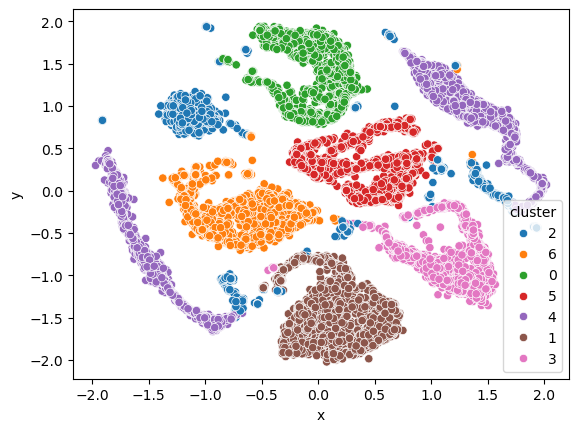

In [53]:
seaborn.scatterplot(data=mde_df,x='x',y='y',hue='cluster')

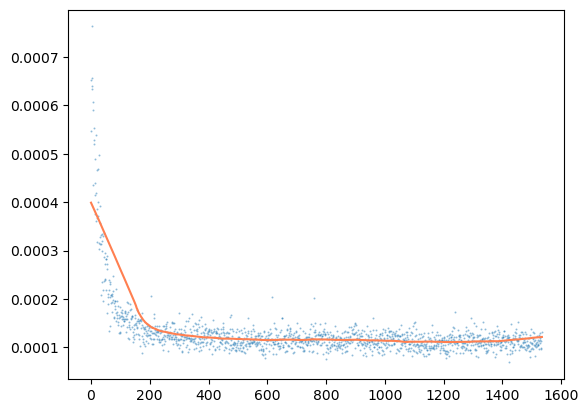

In [24]:
antipode.plotting.plot_loss(losses)

In [25]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = out_locs @ out_transform_matrix + out_intercept
actual_means = locs @ transform_matrix + intercept


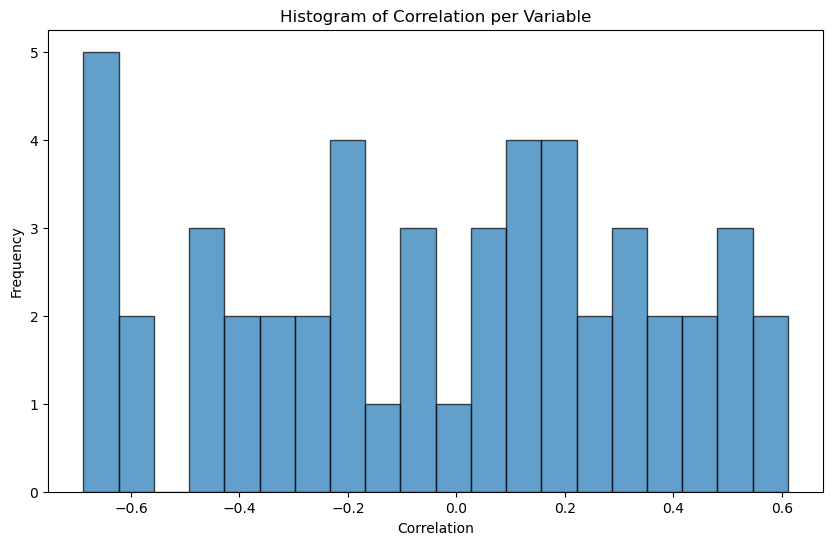

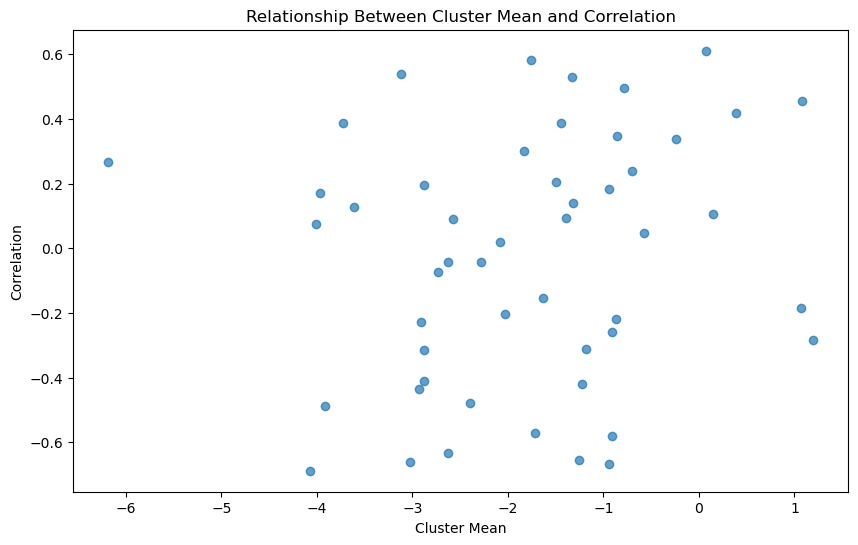

In [26]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(learned_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()
